In [1]:
import pymc as pm
import pymc.sampling_jax as pmj
from pymc import model_to_graphviz
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from utils import load_images
import seaborn as sns
import joblib

seed = 123
rng = default_rng(seed)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (2.0.3) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [2]:
# ica_model = joblib.load("fastica_25x25_100_logcosh.joblib")
A_fname = "fastica_25x25_100_logcosh_aug.npy"
A = np.load(A_fname)
A = A.reshape(int(np.sqrt(A.shape[0])), int(np.sqrt(A.shape[0])), A.shape[-1])
z_dim = A.shape[-1]
print("A.shape:", A.shape)
print("z_dim:", z_dim)

A.shape: (25, 25, 200)
z_dim: 200


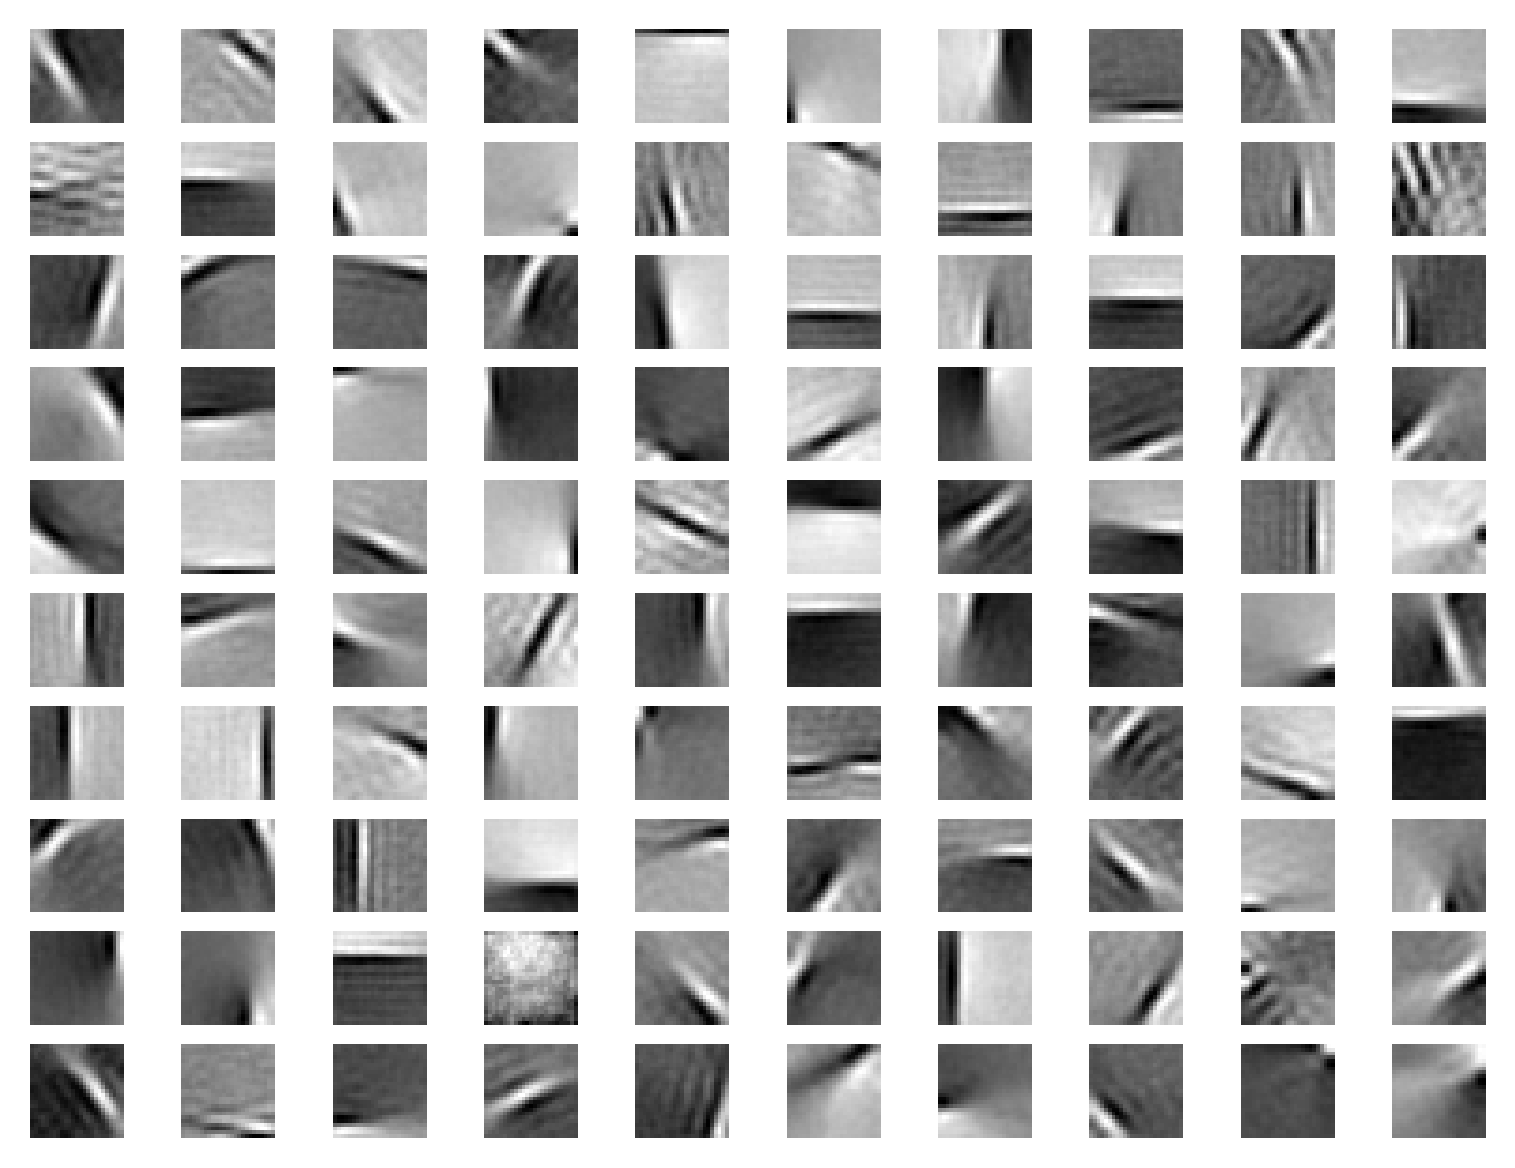

In [3]:
fig, axs = plt.subplots(10, 10, dpi=300)
for i, ax in enumerate(axs.flatten()):
    ax.imshow(A[:, :, i], cmap="gray")
    ax.axis("off")

In [4]:
image_shape = A.shape[:-1]
model = pm.Model()
with model:
    z = pm.Exponential("z", 1, shape=z_dim)
    x = pm.Normal("x", mu=A @ z, sigma=0.1, observed=pm.MutableData("x_obs", rng.random(image_shape)))

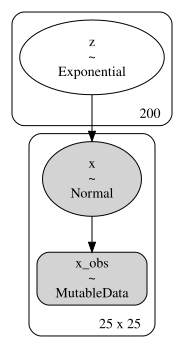

In [5]:
model_to_graphviz(model)

In [6]:
n_samples = 225
with model:
    idata = pm.sample_prior_predictive(n_samples, random_seed=seed)

Sampling: [x, z]


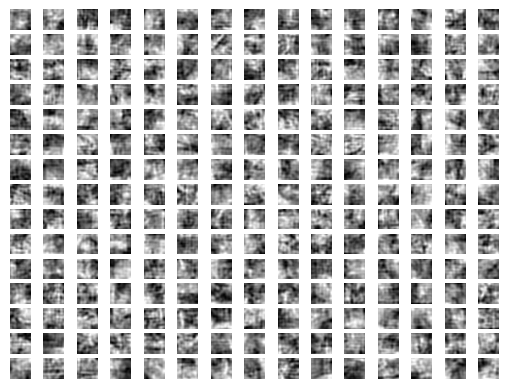

In [7]:
fig, axs = plt.subplots(15, 15, dpi=100)
for i, ax in zip(range(n_samples), axs.flatten()):
    ax.imshow(idata["prior_predictive"]["x"][0, i], cmap="gray")
    ax.axis("off")

In [8]:
images, _ = load_images()

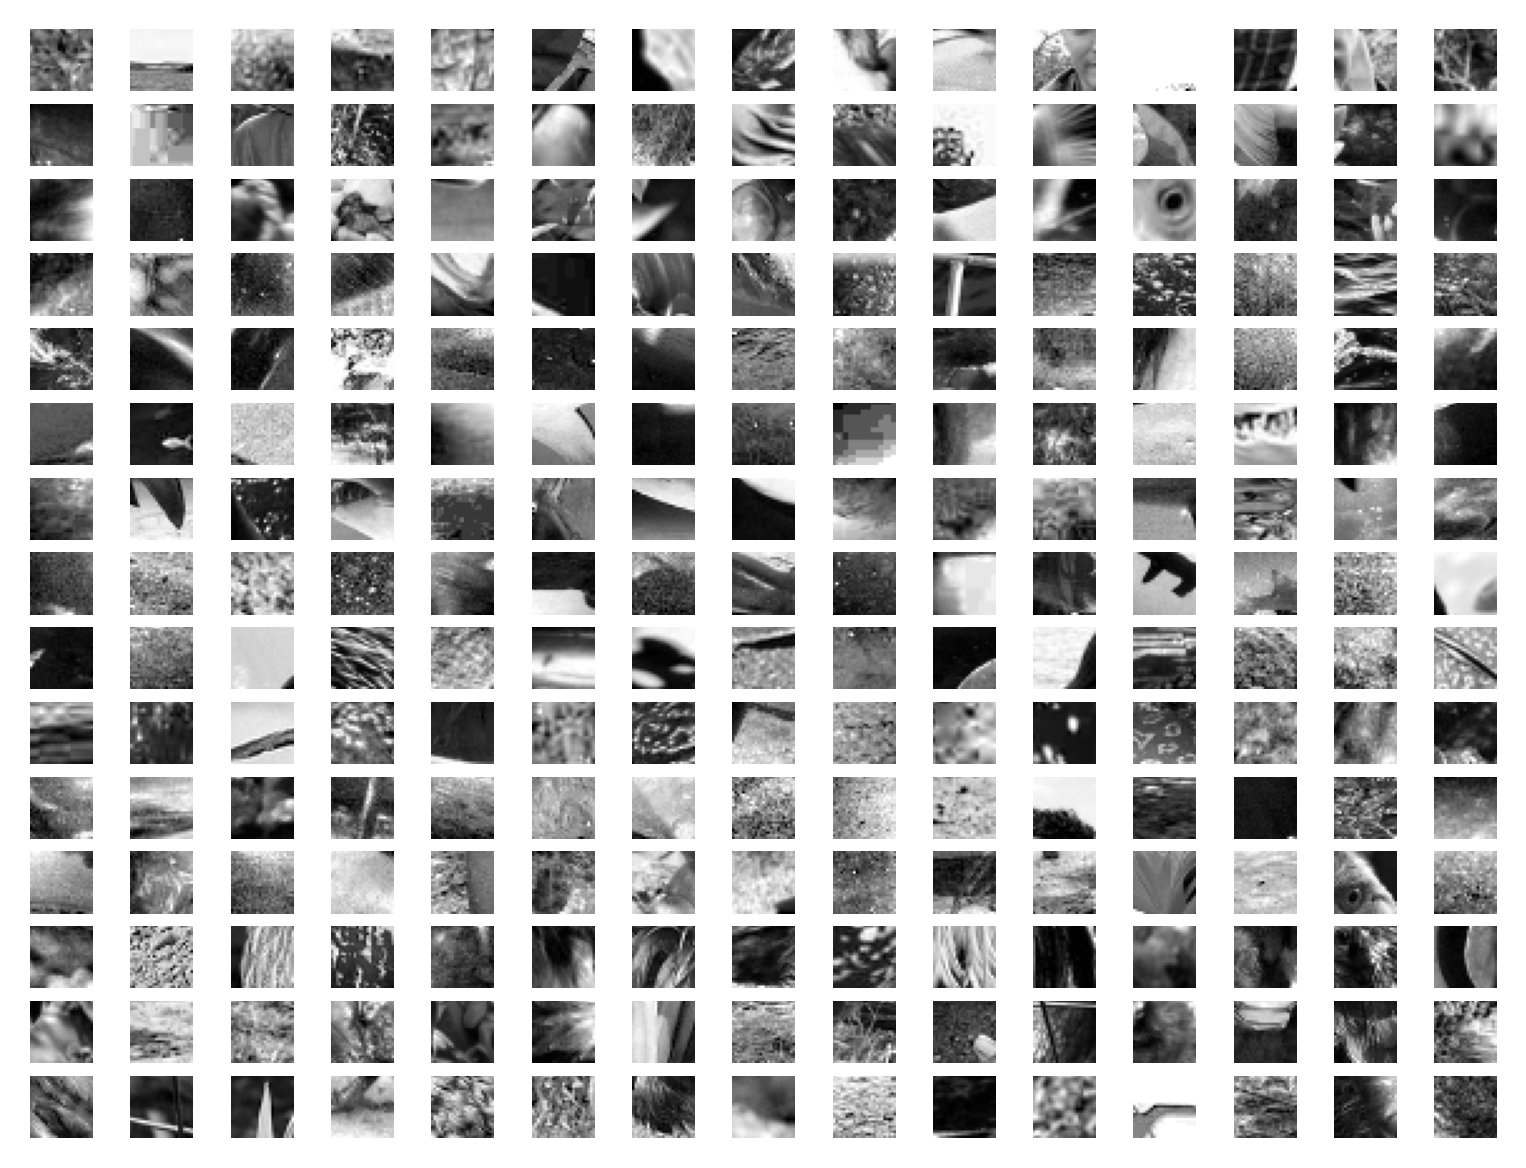

In [9]:
fig, axs = plt.subplots(15, 15, dpi=300)
for i, ax in enumerate(axs.flatten()):
    ax.imshow(images[i].reshape(25, 25).squeeze().numpy(), cmap="gray")
    ax.axis("off")
ax.set_aspect("equal")

In [10]:
sample_image = images[0]
print(images[0].shape)

torch.Size([25, 25])


In [13]:
import pymc.sampling_jax as pmj

In [21]:
draws = 1000
tune = 1000
chains = 1
# cores = 4
return_inferencedata = True
with model:
    pm.set_data({"x_obs": sample_image})
    trace_jax = pmj.sample_numpyro_nuts(
        draws=draws,
        tune=tune,
        chains=chains,
        # cores=cores,
        # return_inferencedata=return_inferencedata,
    )

Compiling...
Compilation time =  0:00:00.531042
Sampling...


sample: 100%|██████████| 2000/2000 [10:45<00:00,  3.10it/s, 1023 steps of size 1.18e-04. acc. prob=0.95]

Sampling time =  0:10:45.315746
Transforming variables...
Transformation time =  0:00:00.011049


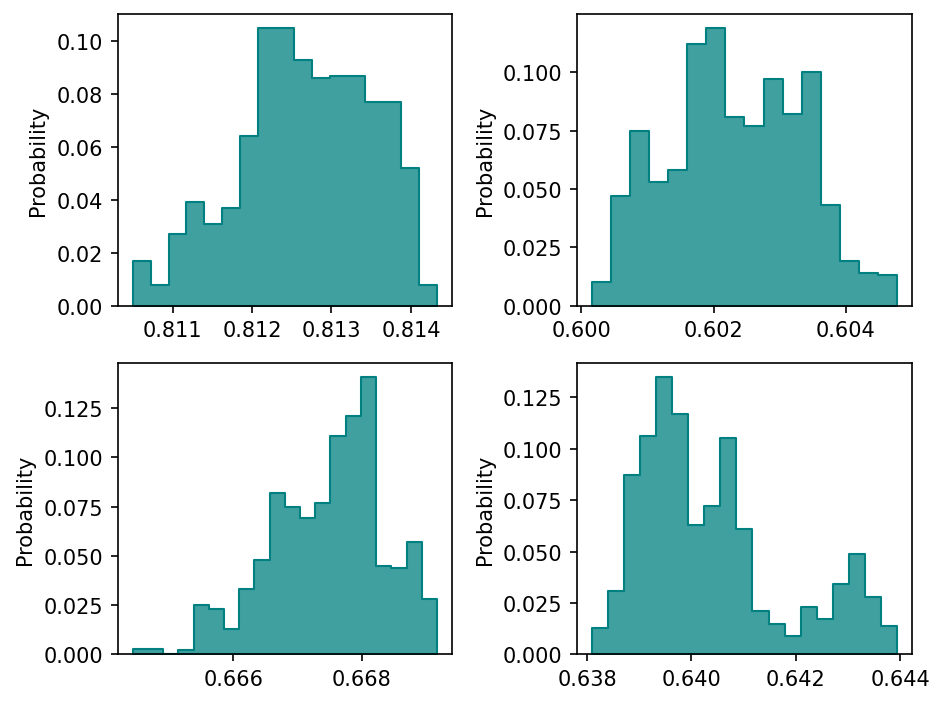

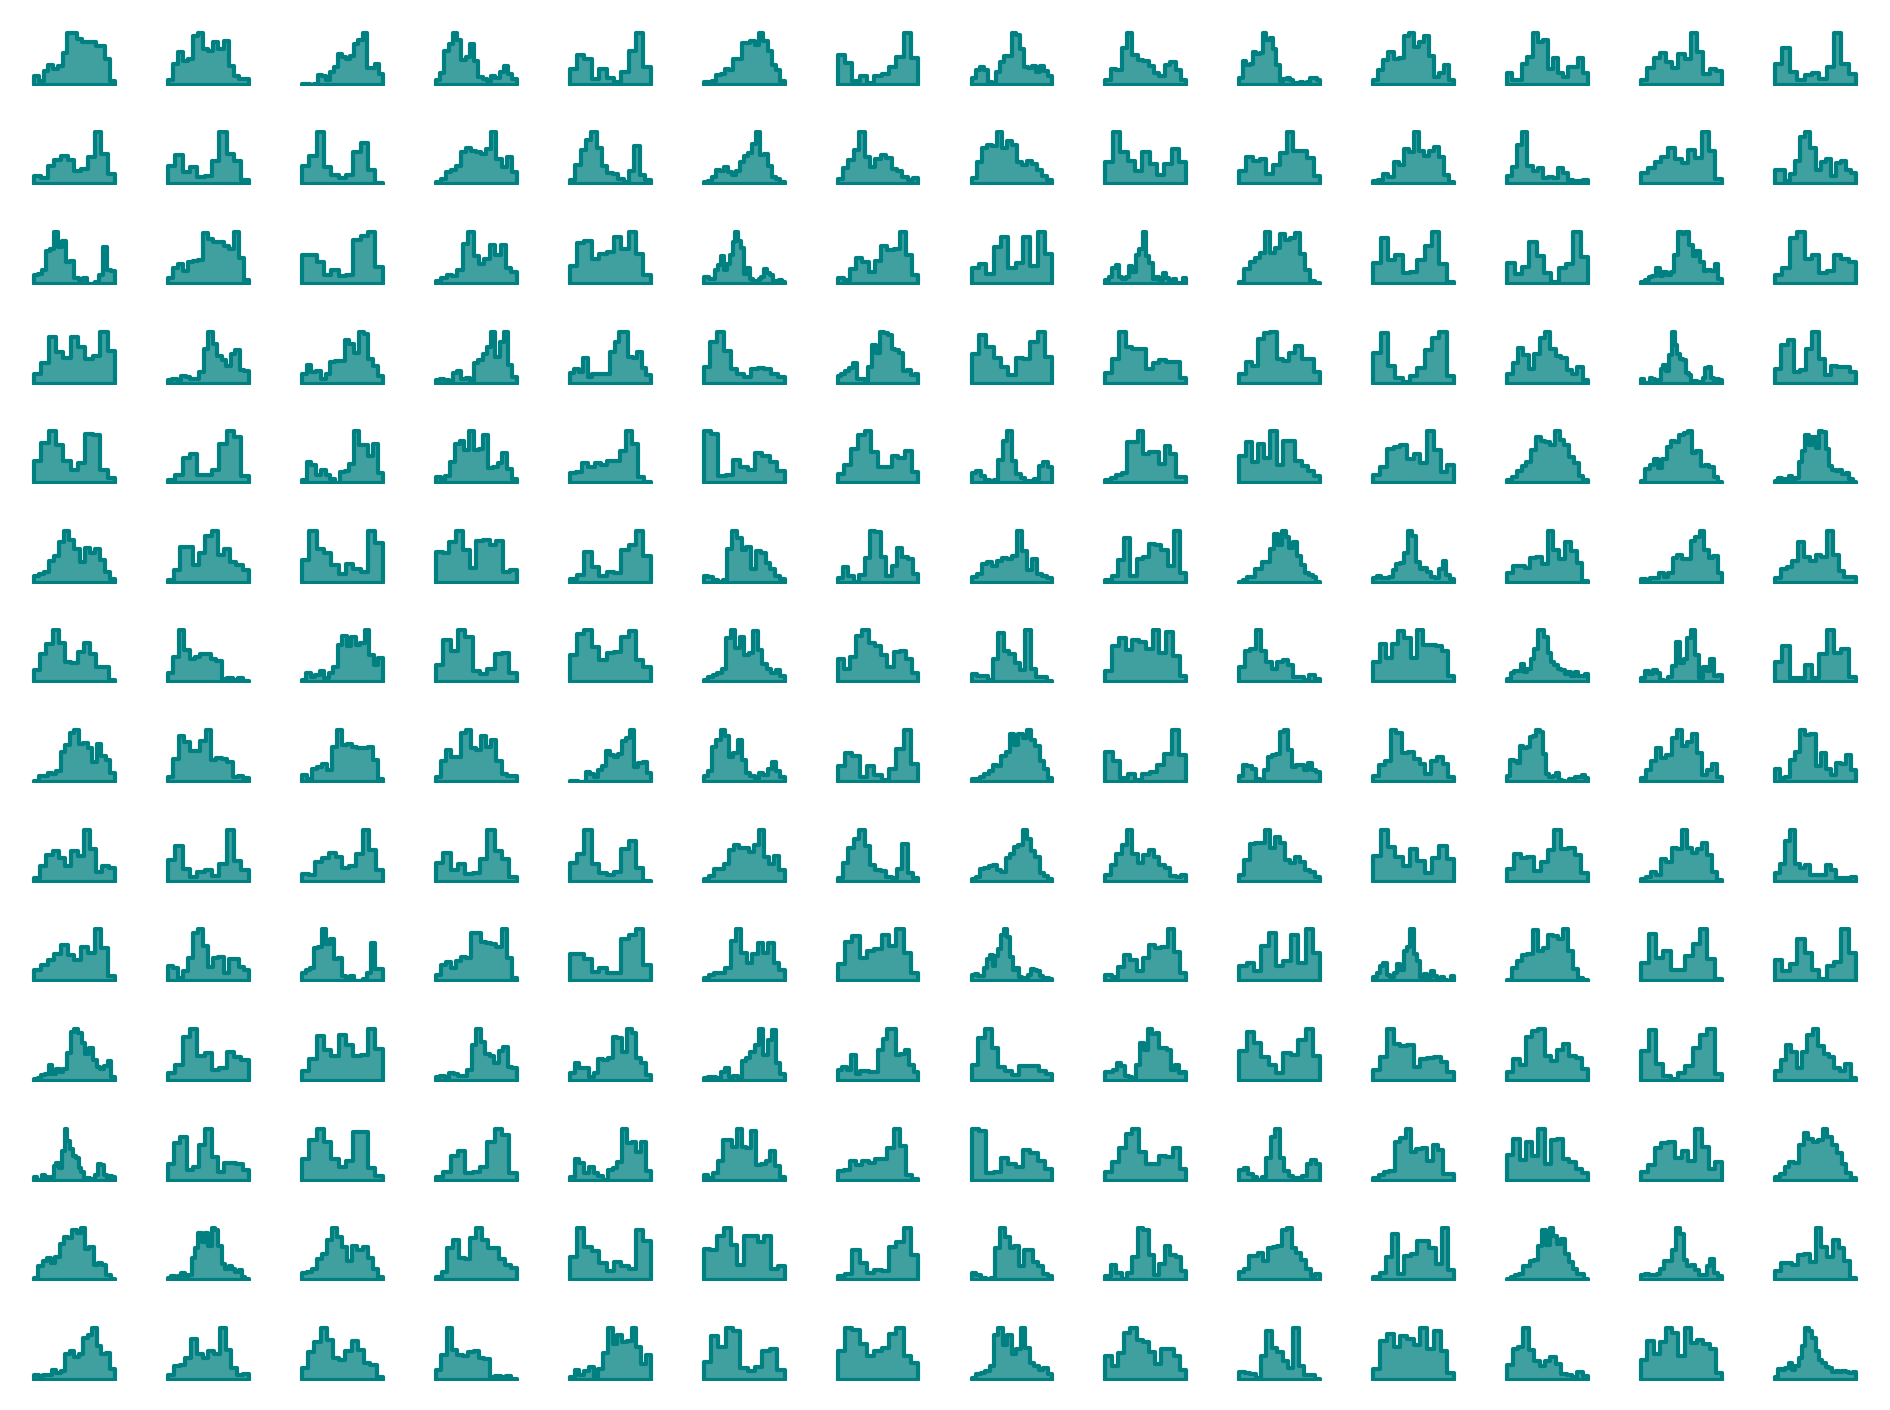

In [22]:
z_post = trace_jax["posterior"]["z"].data
for c in range(chains):
    fig, axs = plt.subplots(2, 2, dpi=150, tight_layout=True)
    for i, ax in zip(range(z_post.shape[-1]), axs.flatten()):
        sns.histplot(z_post[c, :, i], stat="probability", element="step", color="teal", ax=ax)

    fig, axs = plt.subplots(14, 14, dpi=300, tight_layout=True)
    for i, ax in zip(range(z_post.shape[-1]), axs.flatten()):
        sns.histplot(z_post[c, :, i], stat="probability", element="step", color="teal", ax=ax)
        ax.axis("off")

In [23]:
draws = 1000
tune = 1000
chains = 1
cores = 4
return_inferencedata = True
with model:
    pm.set_data({"x_obs": sample_image})
    trace = pm.sample(
        draws=draws,
        tune=tune,
        chains=chains,
        cores=cores,
        # return_inferencedata=return_inferencedata,
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [z]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 9 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


In [24]:
trace["posterior"]

<xarray.Dataset>
Dimensions:  (chain: 1, draw: 1000, z_dim_0: 200)
Coordinates:
  * chain    (chain) int64 0
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 992 993 994 995 996 997 998 999
  * z_dim_0  (z_dim_0) int64 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198 199
Data variables:
    z        (chain, draw, z_dim_0) float64 0.4162 0.9068 1.238 ... 0.7693 1.585
Attributes:
    created_at:                 2023-07-18T13:59:13.863530
    arviz_version:              0.15.1
    inference_library:          pymc
    inference_library_version:  5.6.1
    sampling_time:              9.457767248153687
    tuning_steps:               1000

In [25]:
z_post = trace["posterior"]["z"].data

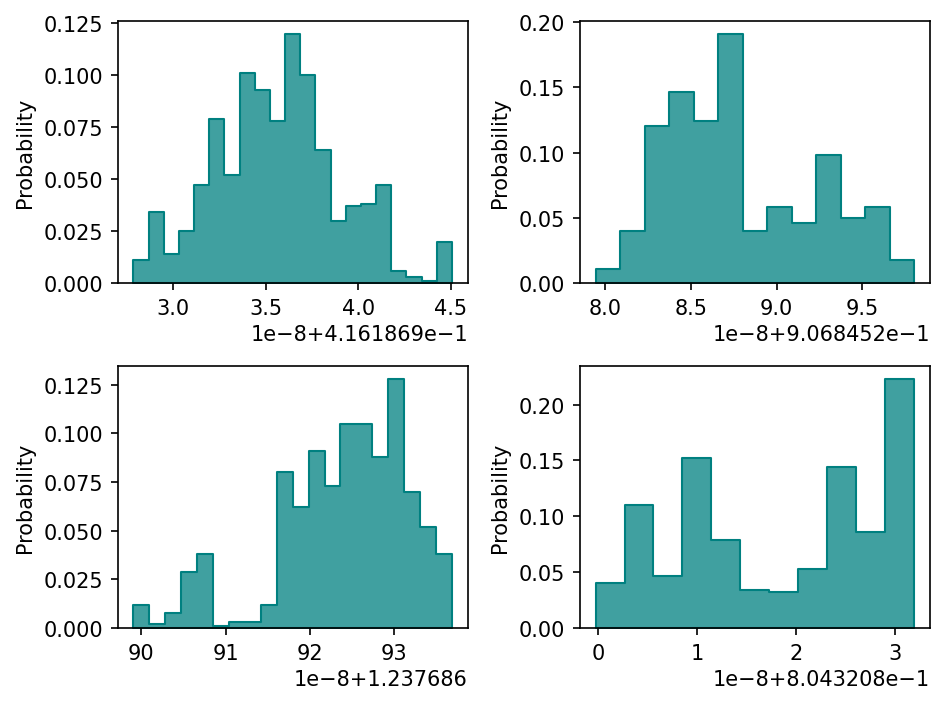

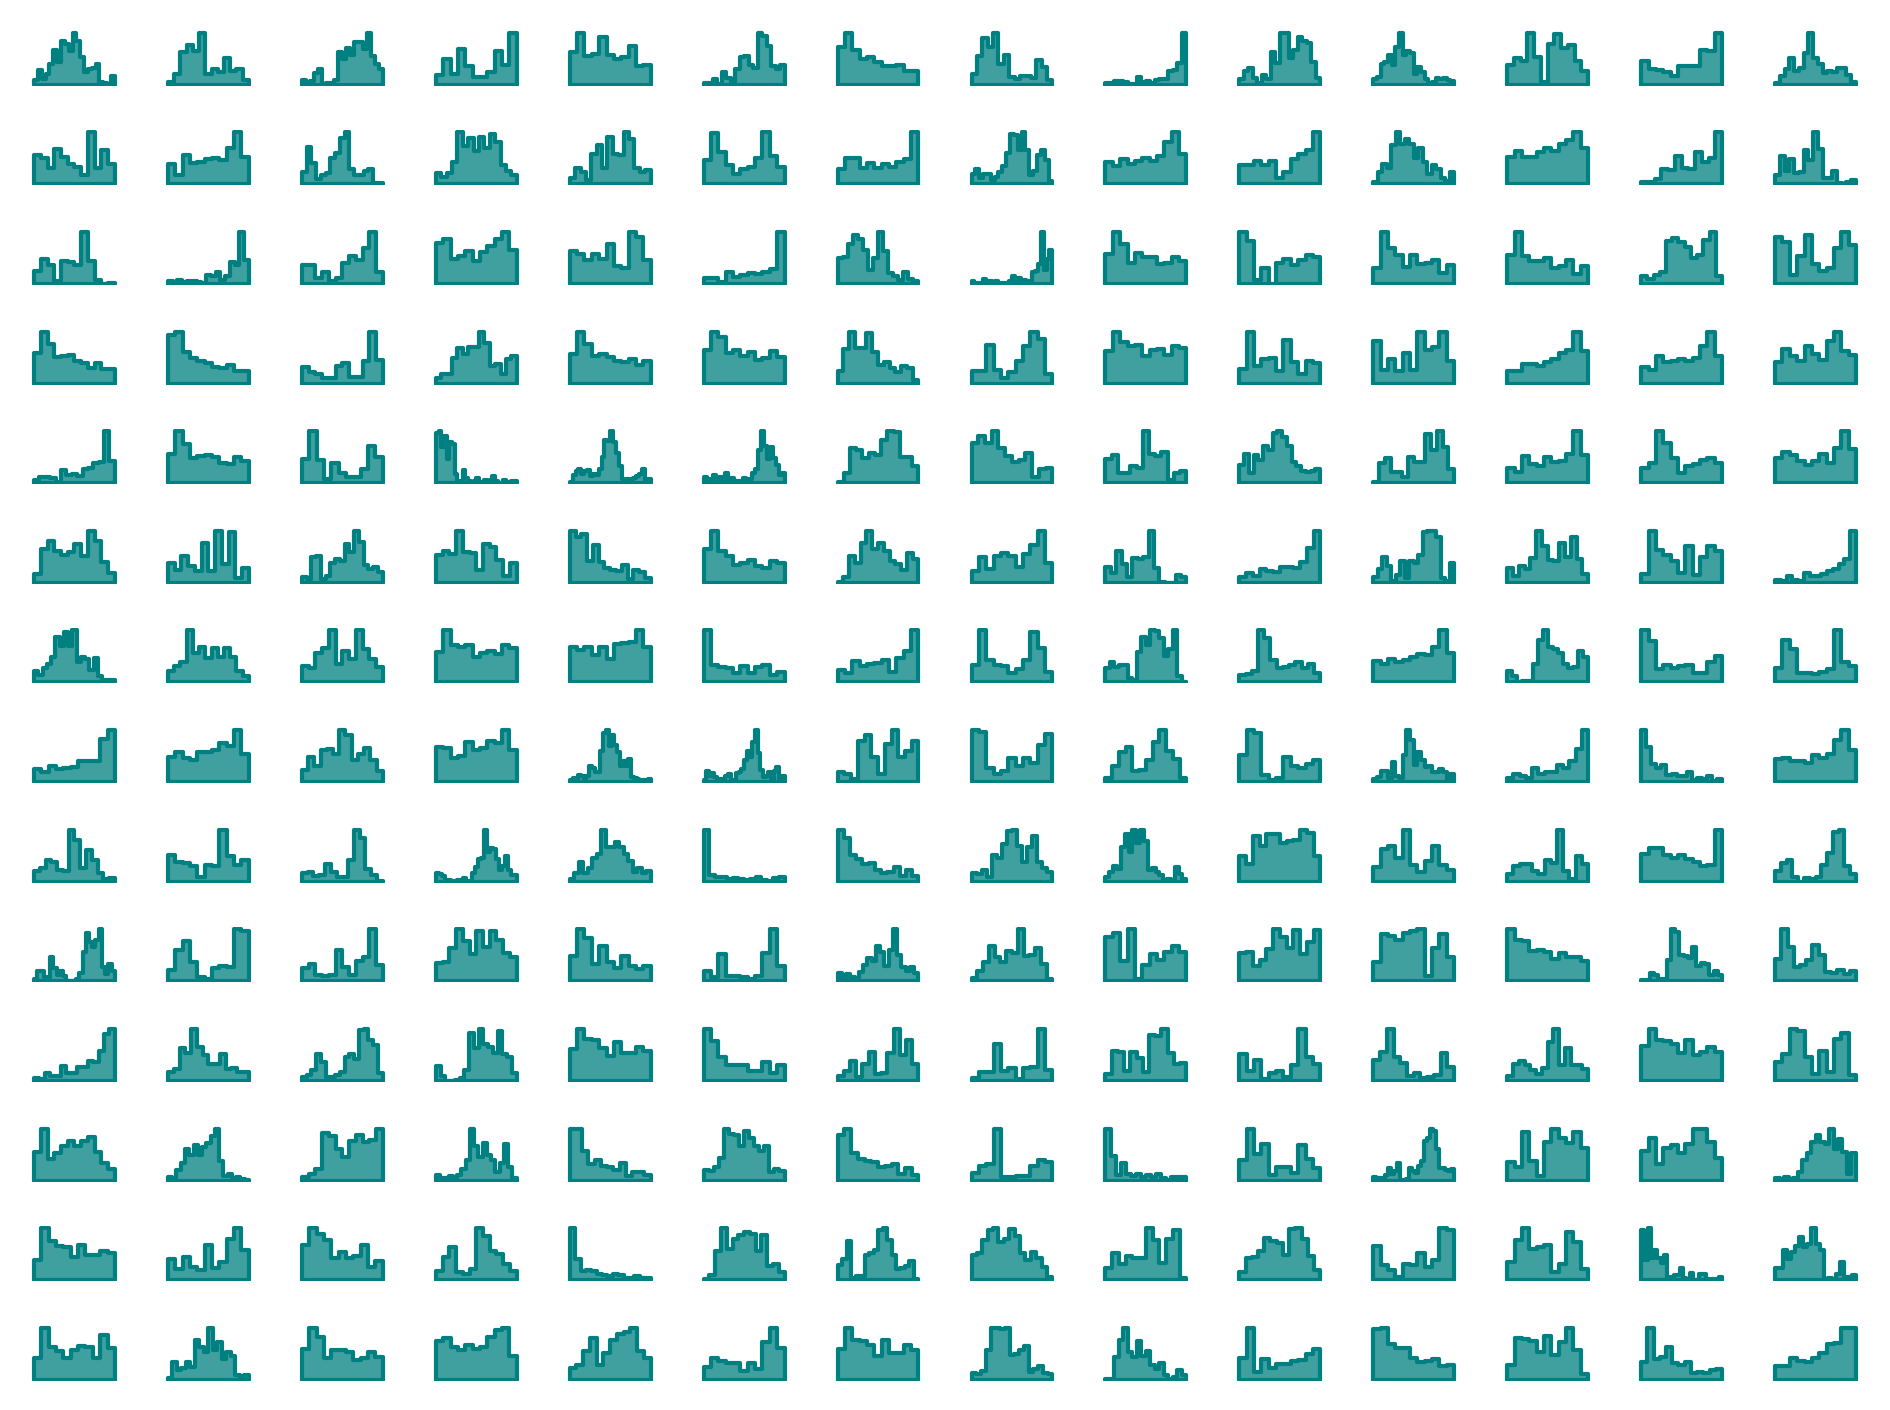

In [26]:
for c in range(chains):
    fig, axs = plt.subplots(2, 2, dpi=150, tight_layout=True)
    for i, ax in zip(range(z_post.shape[-1]), axs.flatten()):
        sns.histplot(z_post[c, :, i], stat="probability", element="step", color="teal", ax=ax)

    fig, axs = plt.subplots(14, 14, dpi=300, tight_layout=True)
    for i, ax in zip(range(z_post.shape[-1]), axs.flatten()):
        sns.histplot(z_post[c, :, i], stat="probability", element="step", color="teal", ax=ax)
        ax.axis("off")

In [27]:
import numpyro
numpyro.set_platform("gpu")

In [29]:
draws = 1000
tune = 1000
chains = 1
# cores = 4
return_inferencedata = True
with model:
    pm.set_data({"x_obs": sample_image})
    trace_jax = pmj.sample_numpyro_nuts(
        draws=draws,
        tune=tune,
        chains=chains,
        chain_method="vectorized",
        # cores=cores,
        # return_inferencedata=return_inferencedata,
    )

Compiling...
Compilation time =  0:00:00.532658
Sampling...


sample: 100%|██████████| 2000/2000 [09:56<00:00,  3.35it/s, 1023 steps of size 1.34e-04. acc. prob=0.93]

Sampling time =  0:09:56.308007
Transforming variables...
Transformation time =  0:00:00.011211
